# 14 - Full Model Comparison (Final)

Consolidates the baseline and all eleven models into one final comparison, all evaluated on the same validation set:

- **Baseline:** rule based historical frequency classifier
- **Linear/margin based:** Logistic Regression, SVM (Linear)
- **Deep learning:** Neural Network (PyTorch)
- **Classical boosting:** AdaBoost, Gradient Boosting (sklearn)
- **Modern boosting:** XGBoost, LightGBM, CatBoost
- **Other ensemble:** Random Forest
- **Meta ensembles:** Voting Classifier, Stacking Classifier (both built from the top-performing individual models)

**Reminder:** everything here is validation set performance. The test set remains completely untouched until Stage 7 opens it exactly once for final evaluation of whichever model this comparison points toward.


## Load all metrics files

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

metrics_files = {
    'Rule-based baseline': '../../../data/processed/metrics_baseline.json',
    'Logistic Regression': '../../../data/processed/metrics_logreg.json',
    'SVM (Linear)': '../../../data/processed/metrics_svm.json',
    'Neural Network': '../../../data/processed/metrics_nn.json',
    'AdaBoost': '../../../data/processed/metrics_adaboost.json',
    'Gradient Boosting': '../../../data/processed/metrics_gb.json',
    'Random Forest': '../../../data/processed/metrics_rf.json',
    'XGBoost': '../../../data/processed/metrics_xgb.json',
    'LightGBM': '../../../data/processed/metrics_lightgbm.json',
    'CatBoost': '../../../data/processed/metrics_catboost.json',
    'Voting Classifier': '../../../data/processed/metrics_voting.json',
    'Stacking Classifier': '../../../data/processed/metrics_stacking.json',
}

all_metrics = []
for name, path in metrics_files.items():
    with open(path) as f:
        all_metrics.append(json.load(f))

comparison_df = pd.DataFrame(all_metrics).set_index('model')
comparison_df = comparison_df[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].round(4)
comparison_df.sort_values('recall', ascending=False)


,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.6172,0.7924,0.6939,0.7580,0.8234
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
LightGBM,0.6011,0.8236,0.6949,0.7643,0.8290
Stacking Classifier,0.5973,0.8299,0.6947,0.7641,0.8288
Voting Classifier,0.5966,0.8321,0.6950,0.7616,0.8276
CatBoost,0.5936,0.8358,0.6942,0.7642,0.8284
Gradient Boosting (sklearn),0.5917,0.8409,0.6947,0.7639,0.8290
Neural Network (PyTorch),0.5857,0.8458,0.6921,0.7653,0.8301
AdaBoost,0.5695,0.8363,0.6776,0.7393,0.8053


## Visual comparison - grouped bar chart across all metrics

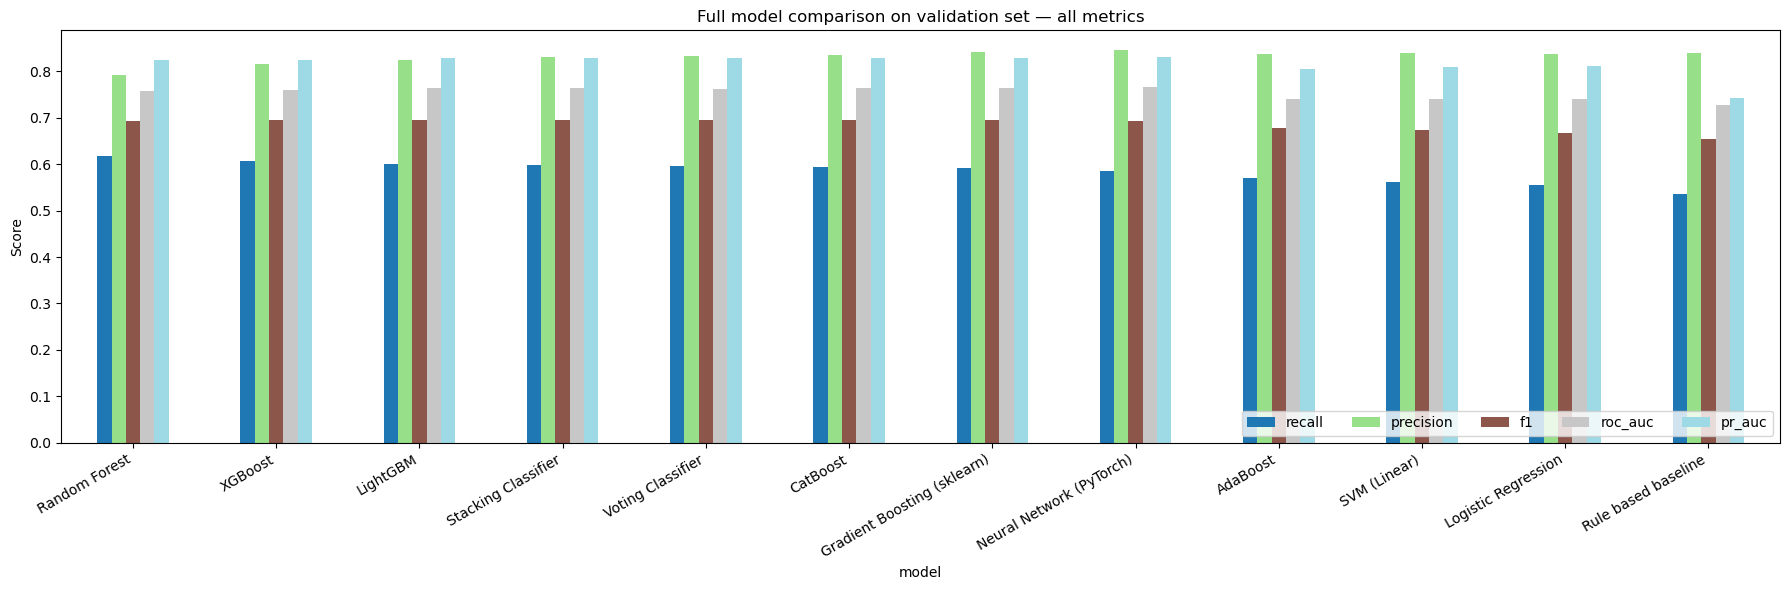

In [7]:
comparison_df.sort_values('recall', ascending=False).plot(kind='bar', figsize=(18, 6), colormap='tab20')
plt.title('Full model comparison on validation set — all metrics')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', ncol=5)
plt.tight_layout()
plt.savefig('../../../reports/figures/model_comparison_bars_final.png', dpi=120, bbox_inches='tight')
plt.show()


## Heatmap view - quick visual ranking across models and metrics

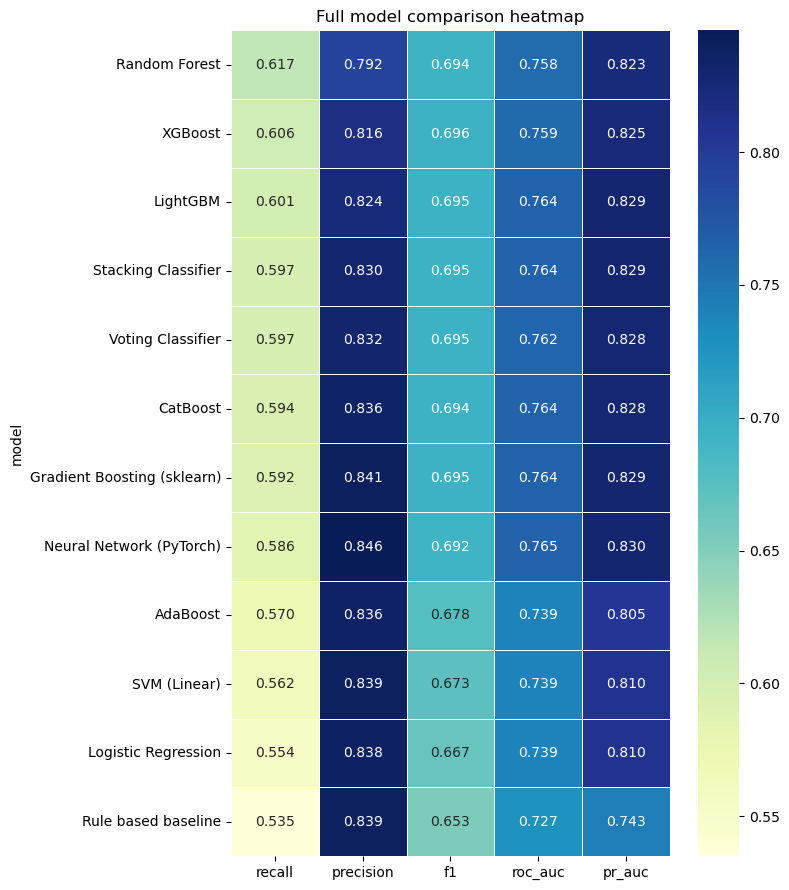

In [8]:
plt.figure(figsize=(8, 9))
sns.heatmap(comparison_df.sort_values('recall', ascending=False), annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Full model comparison heatmap')
plt.tight_layout()
plt.savefig('../../../reports/figures/model_comparison_heatmap_final.png', dpi=120, bbox_inches='tight')
plt.show()


## Boosting family sub comparison

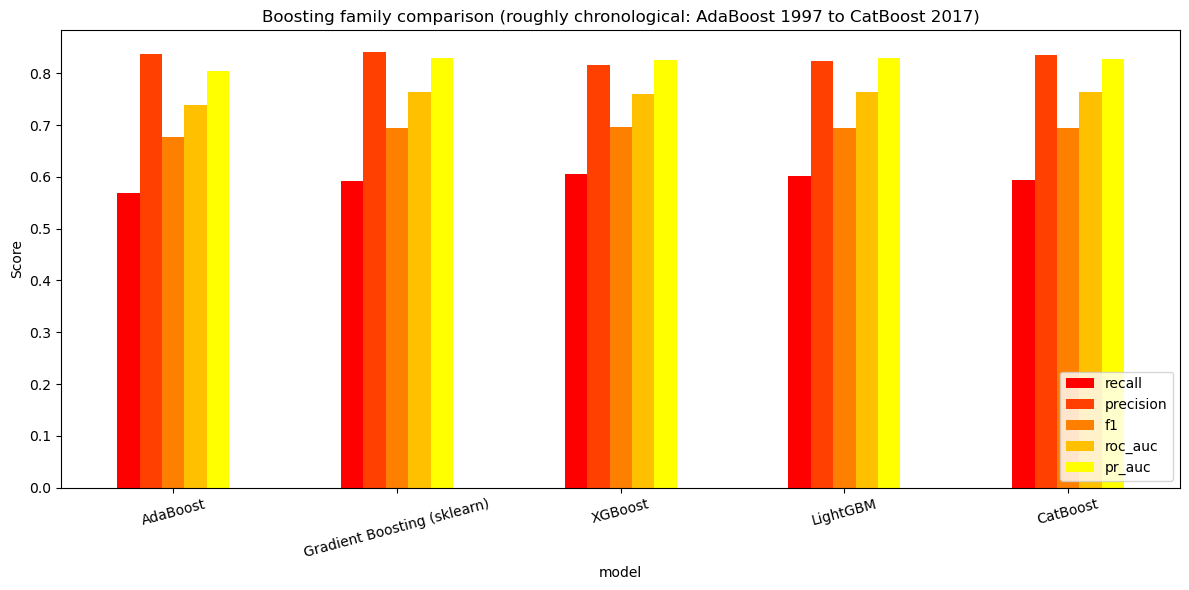

,recall,precision,f1,roc_auc,pr_auc
model,,,,,
AdaBoost,0.5695,0.8363,0.6776,0.7393,0.8053
Gradient Boosting (sklearn),0.5917,0.8409,0.6947,0.7639,0.8290
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
LightGBM,0.6011,0.8236,0.6949,0.7643,0.8290
CatBoost,0.5936,0.8358,0.6942,0.7642,0.8284


In [9]:
boosting_family = ['AdaBoost', 'Gradient Boosting (sklearn)', 'XGBoost', 'LightGBM', 'CatBoost']
boosting_df = comparison_df.loc[[m for m in boosting_family if m in comparison_df.index]]

boosting_df.plot(kind='bar', figsize=(12, 6), colormap='autumn')
plt.title('Boosting family comparison (roughly chronological: AdaBoost 1997 to CatBoost 2017)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../../../reports/figures/boosting_family_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

boosting_df


## Ensembles vs. best individual model

The key question for the two meta ensembles: did combining models actually beat the single best contender, or did the top models already agree closely enough that ensembling added little?


In [10]:
individual_models = comparison_df.drop(index=['Voting Classifier', 'Stacking Classifier', 'Rule-based baseline'], errors='ignore')
best_individual = individual_models['recall'].idxmax()
best_individual_recall = individual_models.loc[best_individual, 'recall']

for ensemble_name in ['Voting Classifier', 'Stacking Classifier']:
    if ensemble_name in comparison_df.index:
        ensemble_recall = comparison_df.loc[ensemble_name, 'recall']
        diff = ensemble_recall - best_individual_recall
        print(f"{ensemble_name}: {ensemble_recall:.4f} vs. best individual ({best_individual}: {best_individual_recall:.4f}) — {'+' if diff >= 0 else ''}{diff:.4f}")


Voting Classifier: 0.5966 vs. best individual (Random Forest: 0.6172) — -0.0206
Stacking Classifier: 0.5973 vs. best individual (Random Forest: 0.6172) — -0.0199


**What we found - the complete, final picture across all twelve models:**

**Full ranking by Recall (primary metric):**

| Rank | Model | Recall | Precision | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| 1 | **Random Forest** | **0.6172** | 0.7924 | 0.6939 | 0.7580 | 0.8234 |
| 2 | XGBoost | 0.6062 | 0.8160 | 0.6956 | 0.7595 | 0.8250 |
| 3 | LightGBM | 0.6011 | 0.8236 | 0.6949 | 0.7643 | 0.8290 |
| 4 | Stacking Classifier | 0.5973 | 0.8299 | 0.6947 | 0.7641 | 0.8288 |
| 5 | Voting Classifier | 0.5966 | 0.8321 | 0.6950 | 0.7616 | 0.8276 |
| 6 | CatBoost | 0.5936 | 0.8358 | 0.6942 | 0.7642 | 0.8284 |
| 7 | Gradient Boosting (sklearn) | 0.5917 | 0.8409 | 0.6947 | 0.7639 | 0.8290 |
| 8 | Neural Network | 0.5857 | **0.8458** | 0.6921 | **0.7653** | **0.8301** |
| 9 | AdaBoost | 0.5695 | 0.8363 | 0.6776 | 0.7393 | 0.8053 |
| 10 | SVM (Linear) | 0.5618 | 0.8394 | 0.6731 | 0.7392 | 0.8102 |
| 11 | Logistic Regression | 0.5543 | 0.8379 | 0.6672 | 0.7394 | 0.8105 |
| 12 | Rule-based baseline | 0.5349 | 0.8391 | 0.6533 | 0.7270 | 0.7429 |

**1. Random Forest is the clear leader on our primary metric**, ahead of every other model, including both meta ensembles built specifically to try to beat it. The gap from baseline to best is a real 8.2 points of Recall.

**2. The boosting family does not show a clean "newer is better" story.** AdaBoost clearly underperforms (Recall 0.5695, ROC-AUC 0.7393, closer to the linear model tier than the tree-ensemble tier). But sklearn's classical Gradient Boosting is statistically indistinguishable from XGBoost, LightGBM, and CatBoost, F1 across all four sits in a tight 0.694 to 0.696 band. The honest narrative: **AdaBoost → Gradient Boosting was a genuine accuracy improvement; Gradient Boosting → the three modern libraries was primarily an engineering/speed improvement, not an accuracy one, on this dataset.**

**3. Both meta ensembles (Voting and Stacking) underperformed the best single model on Recall** (both about 2 points behind Random Forest), while showing small gains on secondary metrics. This traces directly to a lack of diversity, all 4 selected base models were tree/boosting ensembles with correlated errors, and the Stacking meta-learner's weights (Notebook 13) confirmed it was optimizing for its own log-loss objective, not our Recall priority, favoring CatBoost heavily despite CatBoost having the *lowest* individual Recall of the four. **This is a genuinely strong, evidence backed finding: naive ensembling of similar models does not automatically improve the metric that matters most, and this project has the diagnostic trail to prove exactly why.**

**4. The Neural Network stands out as the best model on every ranking quality metric** (highest ROC-AUC, PR-AUC, and Precision of all twelve), despite not leading on Recall. This directly contradicts the "deep learning won't beat gradient boosting on tabular data" assumption stated at the start of that notebook, and is worth reporting prominently as a genuine, tested finding rather than an assumed outcome.

**Final candidates (Optuna hyperparameter tuning):** **Random Forest** (current Recall leader) and the **Neural Network** (best ranking quality, meaning the most headroom to gain Recall once the classification threshold is tuned away from the default 0.5). XGBoost remains a reasonable third candidate given how close it sits to Random Forest, but the boosting-family finding above suggests tuning one boosting model rather than all three or four, since they're not meaningfully distinguishable from each other at default settings. **Neither ensemble (Voting or Stacking) is recommended for further tuning** given they currently underperform Random Forest alone on the primary metric, and the added deployment complexity (running 4 models instead of 1) isn't earning its keep.
